# K Nearest neighbours

> The target of this project is to predict red wine quality from its quemical characteristics
---

#### 0. Library and dataset import

> Note: The 'utils.py' file contains specific functions according to the standards of Exploratory Data Analysis (EDA) and Descriptive Data Analysis (DDA). The functions with the prefix 'eda' are described in the 'utils.py' doc

In [2]:
# Statistic, dataframe and visualization libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ML model related libraries
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ML model wrapper library
from pickle import dump

# Custom functions
import utils as eda

# Dataset
URL = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(URL, sep=';')

df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


---
##### 1.0 Dataset descriptive analysis

> A breif review of the dataset characteristics without involving relations between registered data.

##### 1.1 Dataset general information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Dataset contains 1599 registers on 12 colums. Each row represents a diffent  characteristics set of a wine. 
Column named target will get values a a result of ranging the column named quality.

The dataset does not have null values registered.

All columns contain float type registers, except for column named quality that contains int type values.

#### 1.2 Size and structure

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


> A quick view of metrics above suggest a uniform distribution. No outliers or disruptive data observed.

#### 1.3 Duplicated registers

In [5]:
# duplicates
df.duplicated().sum()


np.int64(240)

> From duplicated values analysis its possible to note that there are 240 rows that contain the same values. Despite the mentioned fact, it does not neccesarily imply duplicity, it´s a possible characterictics similitude. Keep an eye on the mentioned before for later.

In [6]:
# create a new dataset without duplicates
df_2 = df.drop_duplicates().reset_index(drop = True)

> We create a copy of the dataset to compare hoy metrics change if we eliminate duplicated registers.

In [7]:
difference = df.describe().T - df_2.describe().T
difference

,count,mean,std,min,25%,50%,75%,max
fixed acidity,240.0,0.009041,0.004107,0.0,0.0,0.00000,0.000000,0.0
volatile acidity,240.0,-0.001657,-0.003972,0.0,0.0,0.00000,0.000000,0.0
citric acid,240.0,-0.001357,-0.000735,0.0,0.0,0.00000,-0.010000,0.0
residual sugar,240.0,0.015406,0.057614,0.0,0.0,0.00000,0.000000,0.0
chlorides,240.0,-0.000657,-0.002312,0.0,0.0,0.00000,-0.001000,0.0
free sulfur dioxide,240.0,-0.018382,0.012887,0.0,0.0,0.00000,0.000000,0.0
total sulfur dioxide,240.0,-0.358183,-0.513621,0.0,0.0,0.00000,-1.000000,0.0
density,240.0,0.000038,0.000018,0.0,0.0,0.00005,0.000015,0.0
pH,240.0,0.001327,-0.000650,0.0,0.0,0.00000,0.000000,0.0
sulphates,240.0,-0.000556,-0.001160,0.0,0.0,0.00000,0.000000,0.0


> No drastic changes observed.

#### 1.4 "0" value records

In [8]:
print((df == 0).sum())

fixed acidity             0
volatile acidity          0
citric acid             132
residual sugar            0
chlorides                 0
free sulfur dioxide       0
total sulfur dioxide      0
density                   0
pH                        0
sulphates                 0
alcohol                   0
quality                   0
dtype: int64


The result shows that only the citric acid column has "0" values (132 records). This does not necessarily indicate an error and must be investigated.

After consulting it, the answer is as follows:

Why might there be 0 citric acid in a wine?
Citric acid is a naturally organic acid that is contained in small amounts in wine.
It can be added during winemaking to increase acidity, improve flavor, or stabilize color.
However, not all wines have detectable or added citric acid. Some producers do not use it, acid degrades as time passes by.
Especially on less expensive wines, citric acid may not be added as part of the process.

Regarding on above, the decition is to not delete or replace "0" dataset values.

#### 1.5 Visualization and data distribution

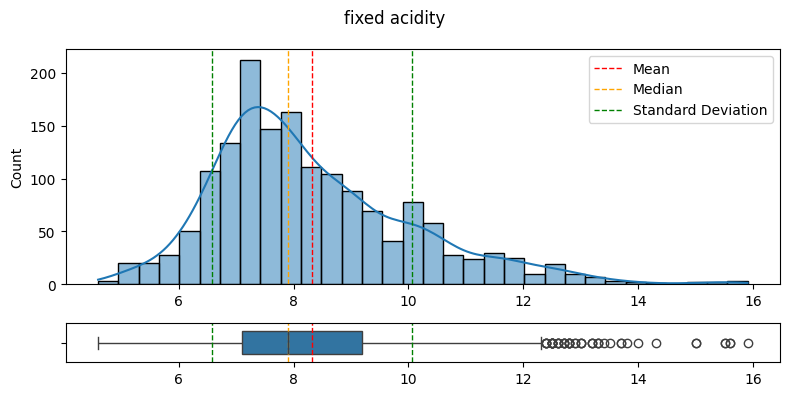

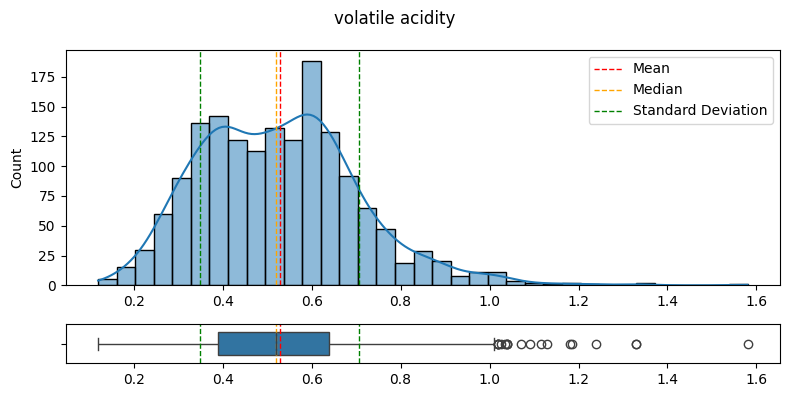

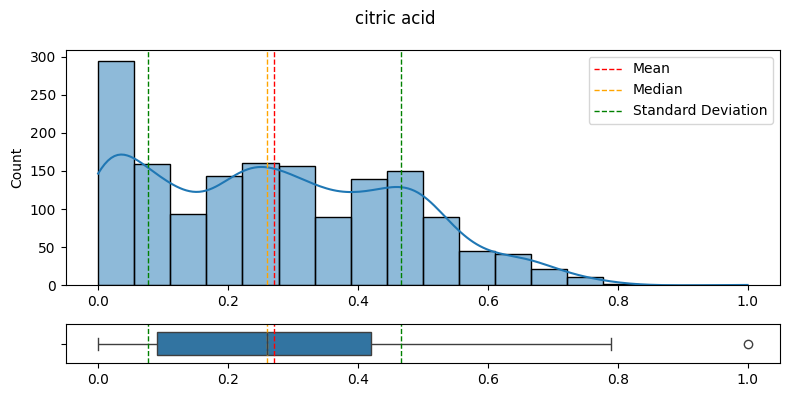

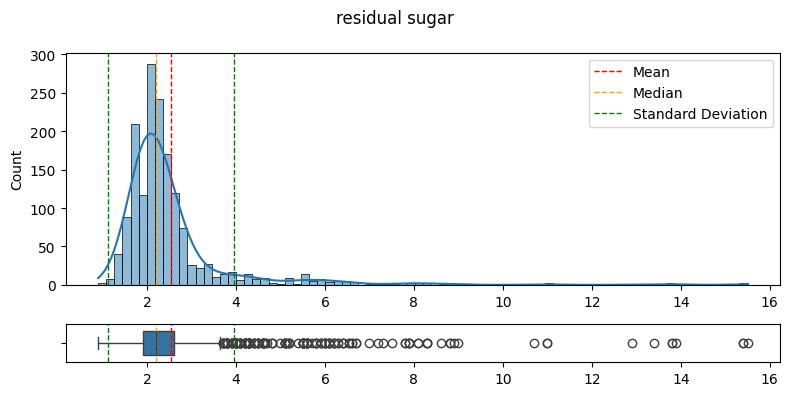

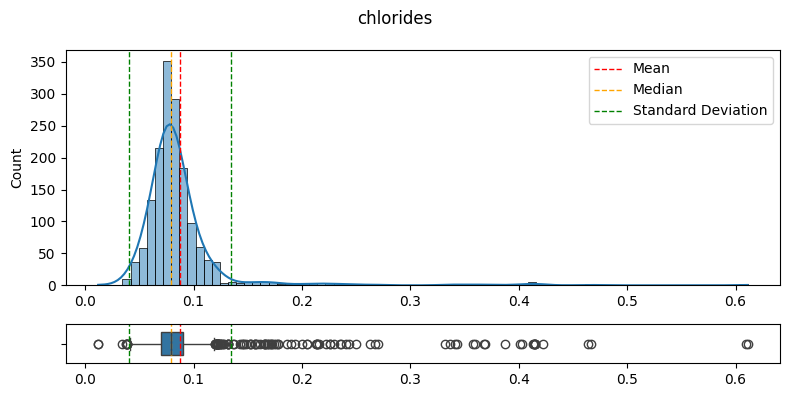

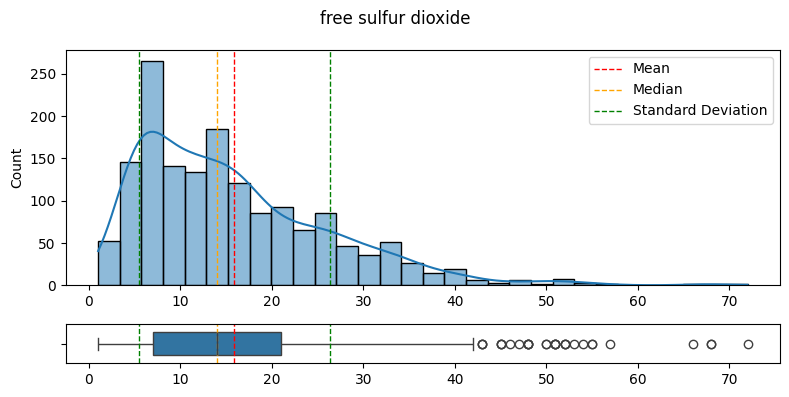

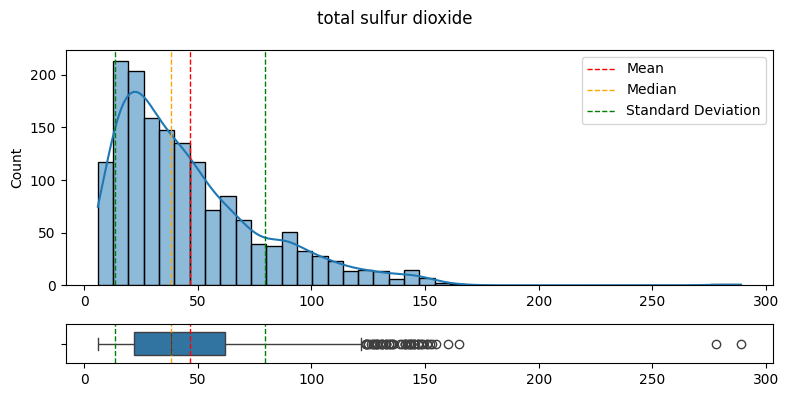

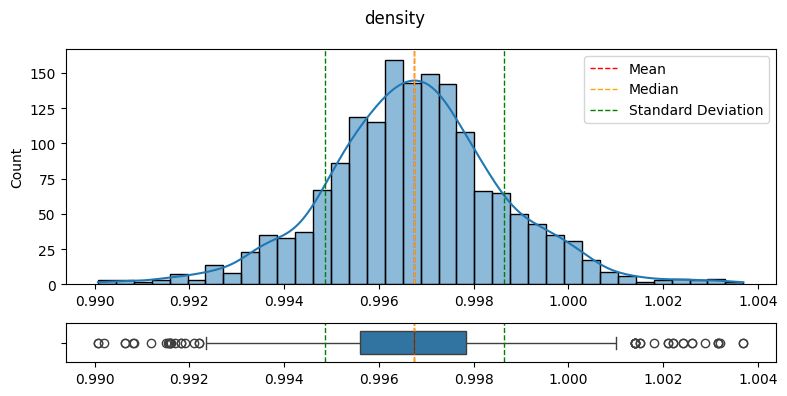

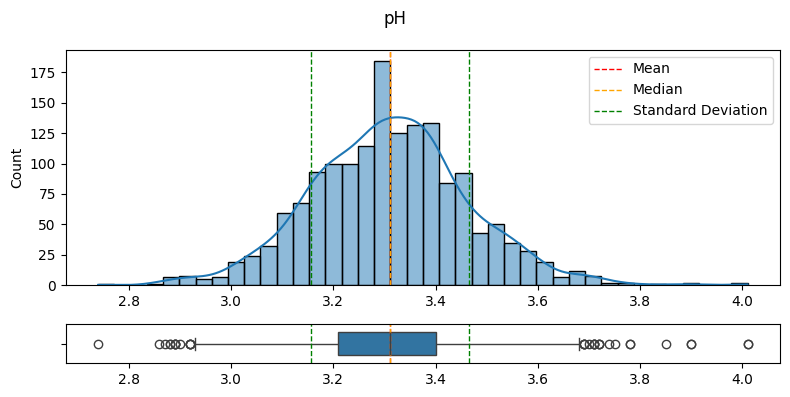

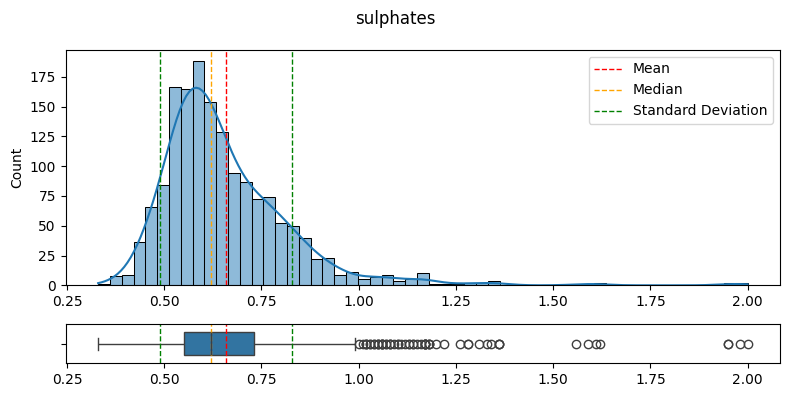

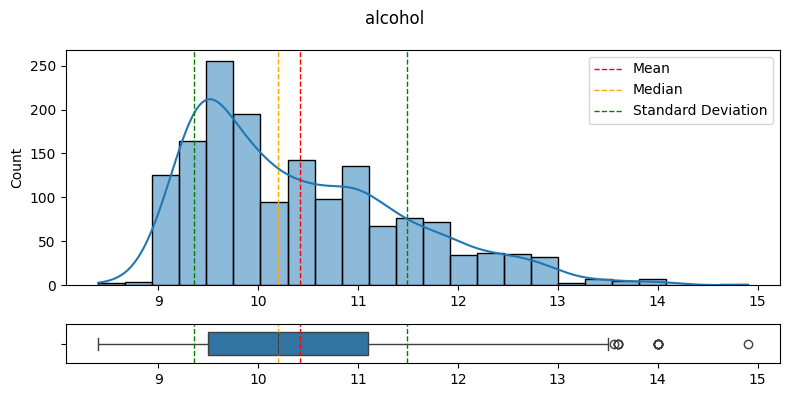

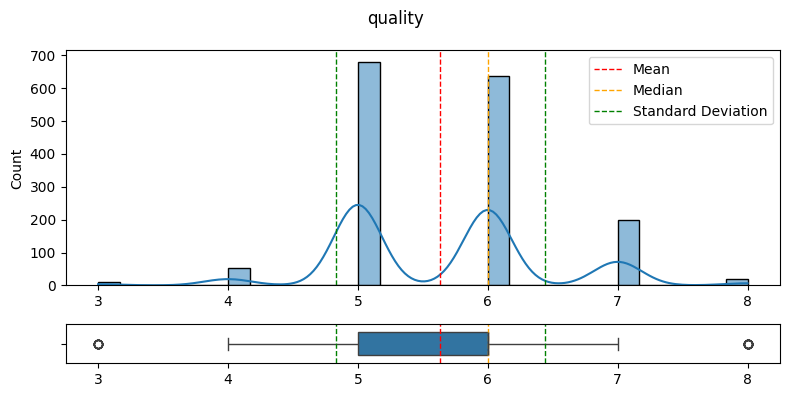

In [9]:
eda.plot_numerical_data(df)

> We confirm as mentioned at the begining. No noisy records and uniform distributions.
---

### 2. Exploratory data analysis (EDA)

#### 2.1 Target variable definition

The target variable is defined as 0, 1, or 2, depending on wine's quality values. This records will be taken from this mentioned column.

Quality column cotains the following records: 3, 4, 5, 6, 7, and 8.

Records 3 and 4 will be scaled as 0.

Records 5 and 6 will be scaled as 1.

Records 7 and 8 will be scaled as 2.

In [10]:
# función de división
def categorizar_calidad(valor):
    if valor <= 4:
        return 0
    elif valor <= 6:
        return 1
    else:
        return 2


In [11]:
# aplicar funcion de división
df['label'] = df['quality'].apply(categorizar_calidad)

In [12]:
# eliminar columna quality
df = df.drop(columns=['quality'])
# visualizar dataset con target
df.head(3)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,1


In [13]:
target = 'label'

#### Final clasification label distribution is:

> 63 Low quality label wine.

> 1319 medium quality label wine.

> 217 high quality label wine.

#### 2.2 Multivariable analysis

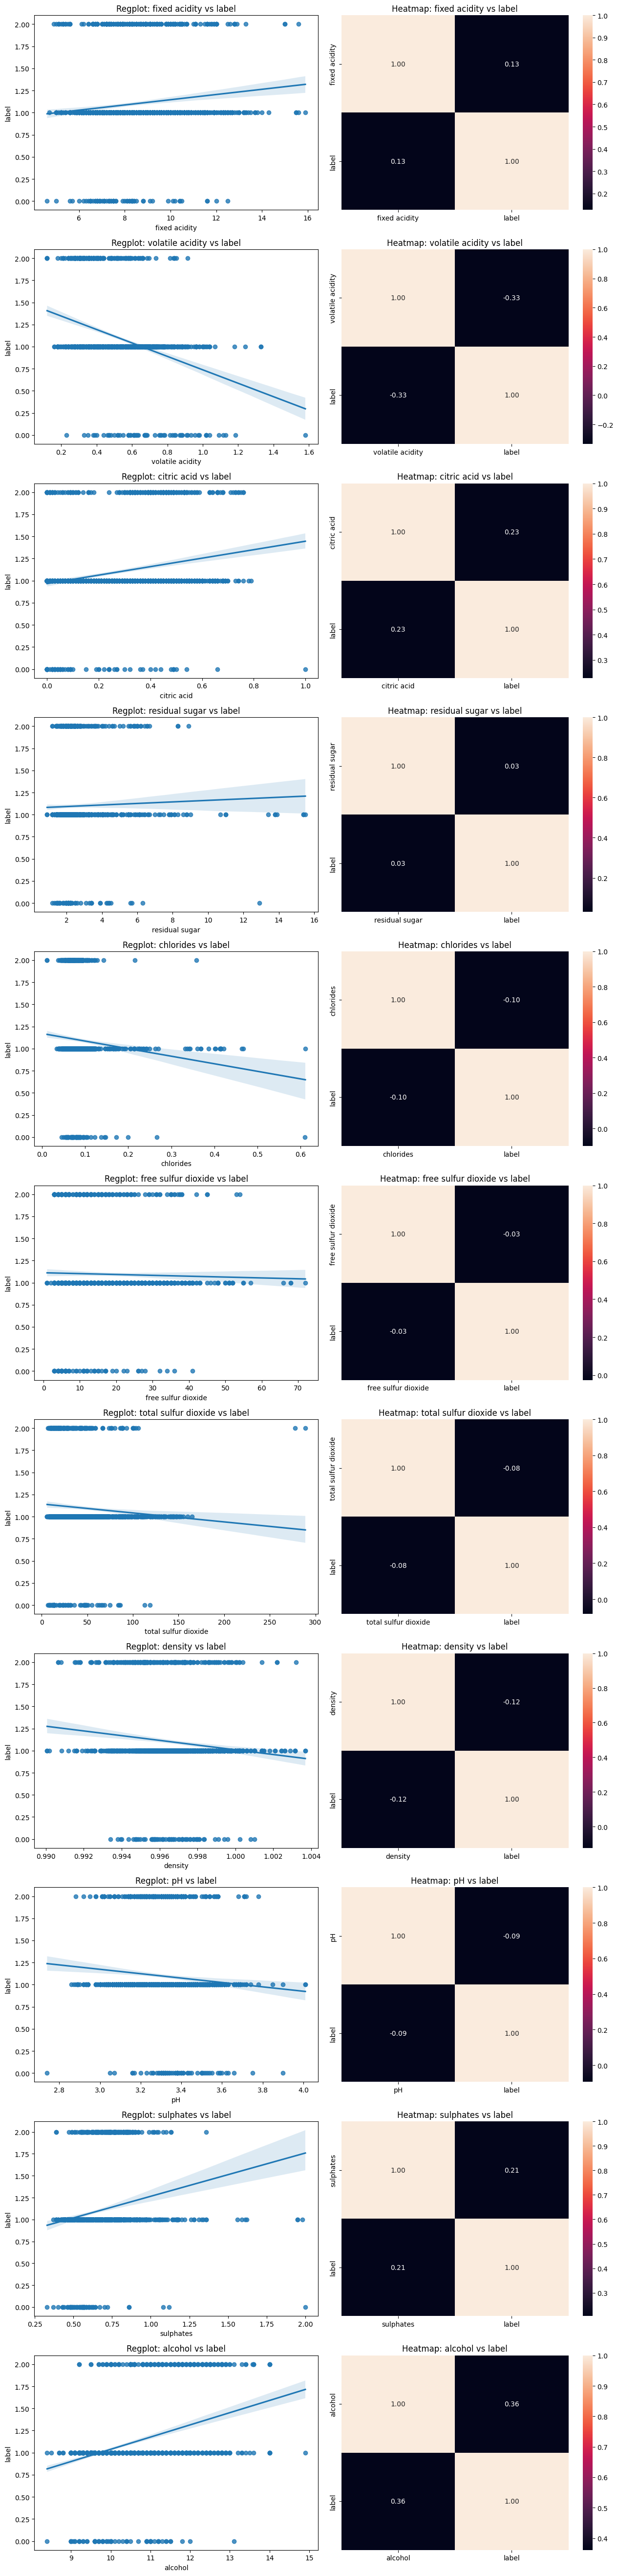

In [14]:
# funcion custom para heatmaps
eda.plot_scatter_heatmaps(df,target)

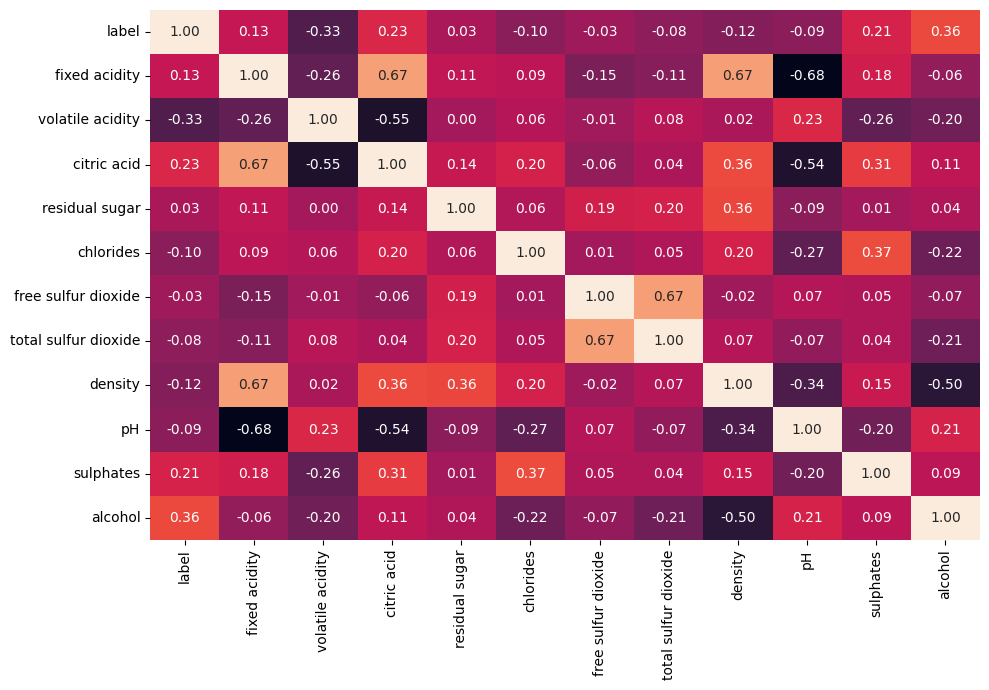

In [18]:
eda.general_heatmap(df,target)

#### Highest correlated varaibles are:

volatile acidity : 0.33

citric acid : 0.23

sulphates : 0.21

alcohol : 0.36

In [19]:
early_df = df.copy()

> Antes de modelar, respaldamos una copia del dataset.

### 3. Feature Engineering

#### 3.1. Outliers

At the begining of the project we verified the existance of statistic outliers, these do not represent errors, these are just different records.

#### 3.2 Separar las variables independientes (X) del objetivo (y)

In [20]:
X = df.drop(columns=['label'])
y = df['label']

#### División de datos

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Escalado de datos

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Tamaño y forma de conjuntos de entrenamiento

In [ ]:
X_train_scaled.shape, X_test_scaled.shape, y_train.shape, y_test.shape

((1279, 11), (320, 11), (1279,), (320,))

#### Entrenar modelo KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


##### Predicción

In [ ]:
y_pred = knn.predict(X_test_scaled)

#### Evaluación y resultados

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.81875

Confusion Matrix:
 [[  0  13   0]
 [  1 243  20]
 [  0  24  19]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.87      0.92      0.89       264
           2       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



#### Búsqueda del mejor valor de K

In [ ]:
k_range = range(1, 21)
accuracies = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)
acc

0.840625

> Accuracy más alta obtenida es de 84.06%

#### Visualizar accuracy vs K para notar tendencia

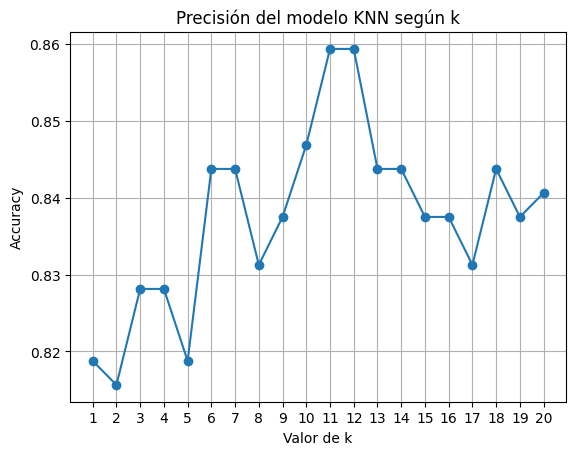

In [ ]:
plt.plot(k_range, accuracies, marker='o')
plt.xlabel('Valor de k')
plt.ylabel('Accuracy')
plt.title('Precisión del modelo KNN según k')
plt.xticks(k_range)
plt.grid(True)
plt.show()

#### Guardar modelo

In [ ]:
dump(knn, open("wine_quality_red.sav", "wb"))